Compares the estimated standard deviation between the ML and the empirical cIM approach
The aim is to see if the ML model is in line with the empirical cIM approach for the synthethic dataset.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr
import ml_tools as mlt

In [2]:
ml_results_dir=  Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0703_0839syn_lb_20_100_SCweighted_L2Bal_perIM")
emp_results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [3]:
def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)

In [4]:
# Load the data
meta = mlt.utils.load_yaml(ml_results_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

val_sc_sum_df = pd.read_parquet(ml_results_dir / "val_scenario_summary.parquet")
train_sc_sum_df = pd.read_parquet(ml_results_dir / "train_scenario_summary.parquet")

db = sr.db.DB(db_ffp)

In [9]:
val_emp_mean_df, val_emp_std_df, val_sc_sum_df = sr.data.get_overlap_emp_ml_data(emp_results_dir, val_sc_sum_df)
train_emp_mean_df, train_emp_std_df, train_sc_sum_df = sr.data.get_overlap_emp_ml_data(emp_results_dir, train_sc_sum_df)

Overlapping scenarios: 605/605
Overlapping scenarios: 2420/2420


In [10]:
ml_std_cols = [f"{cur_key}_wstd" for cur_key in sr.constants.PSA_KEYS]

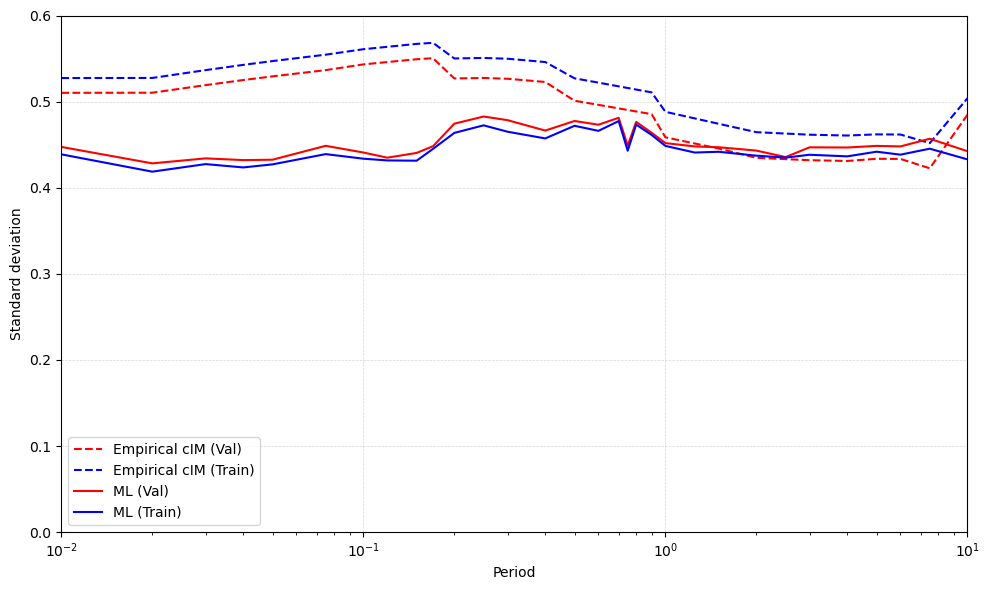

In [23]:
# Plot the standard deviation of the ML and the empirical cIM approach
fig = plt.figure(figsize=(10, 6))

plt.semilogx(sr.constants.PERIODS, val_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Val)", c="r", linestyle="--")
plt.semilogx(sr.constants.PERIODS, train_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Train)", c="b", linestyle="--")

plt.semilogx(sr.constants.PERIODS, val_sc_sum_df[ml_std_cols].mean(), label="ML (Val)", c="r")
plt.semilogx(sr.constants.PERIODS, train_sc_sum_df[ml_std_cols].mean(), label="ML (Train)",  c="b")

plt.xlabel("Period")
plt.ylabel("Standard deviation")
plt.legend()
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")

plt.xlim(0.01, 10)
plt.ylim(0, 0.6)

fig.tight_layout()
plt.show()


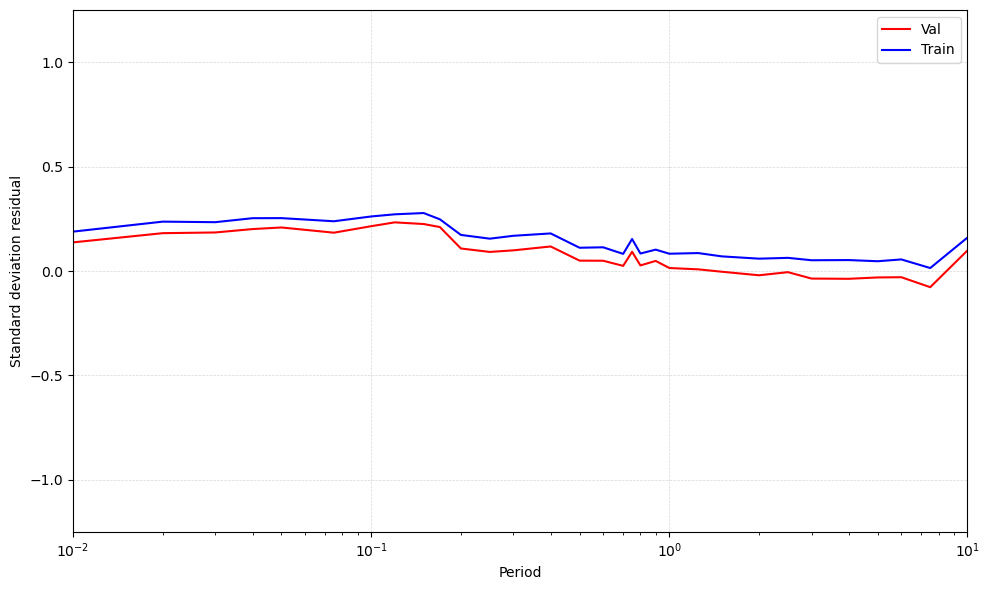

In [22]:
# Plot the residual between the standard deviations of the ML and the empirical cIM approach
val_std_res = np.log(val_emp_std_df[sr.constants.PSA_KEYS].values)  - np.log(val_sc_sum_df[ml_std_cols].values)
train_std_res = np.log(train_emp_std_df[sr.constants.PSA_KEYS].values) - np.log(train_sc_sum_df[ml_std_cols].values)

fig = plt.figure(figsize=(10, 6))

plt.semilogx(sr.constants.PERIODS, val_std_res.mean(axis=0), label="Val", c="r")
plt.semilogx(sr.constants.PERIODS, train_std_res.mean(axis=0), label="Train", c="b")

plt.xlabel("Period")
plt.ylabel("Standard deviation residual")
plt.legend()
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")

plt.xlim(0.01, 10)
plt.ylim(-1.25, 1.25)

fig.tight_layout()